In [190]:
import uproot
import matplotlib.pyplot as plt
from matplotlib import ticker
import numpy as np
import mplhep as mplhep

In [191]:
ROOT_FOLDER = "/sdf/home/d/dhruvshr/ePix_Simulation/Examples/PixelSim_ePix/sparse_sim_outputs/"
filenames = ["sparse_sim_run_001.root", "sparse_sim_run_002.root"]
files = [(uproot.open(ROOT_FOLDER + filename)) for filename in filenames]

In [192]:
edeps = []
hits = []
xedges = []
yedges = []
for file in files:
    edep_vals, xedges, yedges = file['EdepHeatMap'].to_numpy()
    edep_vals = edep_vals * 1000
    hits_vals = file['HitsHeatMap'].to_numpy()[0]
    edeps.append(edep_vals)
    hits.append(hits_vals)

xedges *= 10
yedges *= 10

In [193]:
output = files[0]
output.keys()

['PixelEdep;1', 'EdepHeatMap;1', 'HitsHeatMap;1']

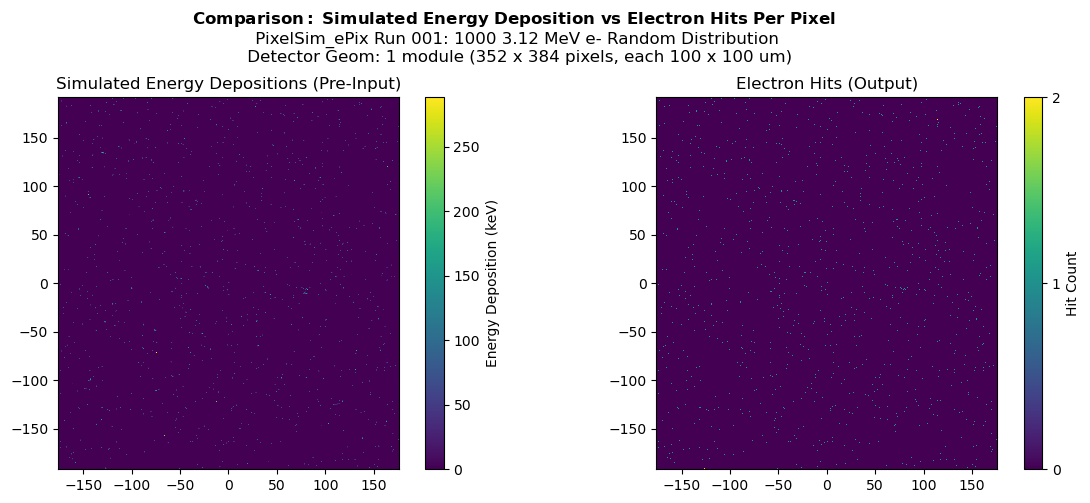

In [194]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
plt.suptitle(r'$\bf{Comparison:\ Simulated\ Energy\ Deposition\ vs\ Electron\ Hits\ Per\ Pixel\ }$' + 
          f" \n PixelSim_ePix Run 001: {int(np.sum(hits[0]))} 3.12 MeV e- Random Distribution " + 
          "\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um)");

ax[0].set_aspect('equal')
outputs = ax[0].pcolormesh(xedges, yedges, edeps[0].T, cmap='viridis')
ax[0].set_title("Simulated Energy Depositions (Pre-Input)")
fig.colorbar(outputs,label="Energy Deposition (keV)",ax=ax[0]);

ax[1].set_aspect('equal')
inputs = ax[1].pcolormesh(xedges, yedges, hits[0].T, cmap='viridis')
ax[1].set_title("Electron Hits (Output)")
cbar=fig.colorbar(inputs,label="Hit Count",ax=ax[1])
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

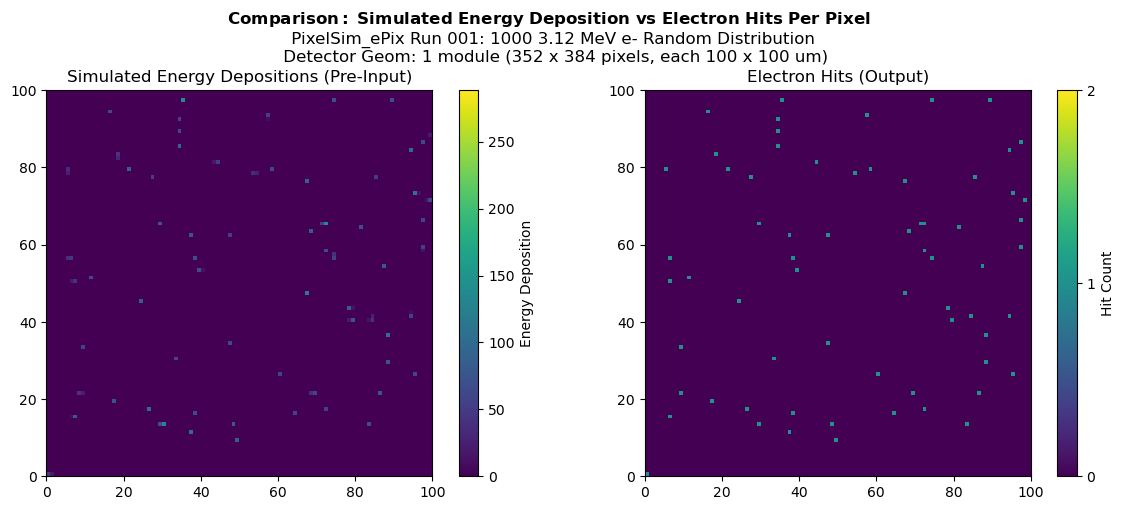

In [195]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
plt.suptitle(r'$\bf{Comparison:\ Simulated\ Energy\ Deposition\ vs\ Electron\ Hits\ Per\ Pixel\ }$' + 
          f" \n PixelSim_ePix Run 001: {int(np.sum(hits[0]))} 3.12 MeV e- Random Distribution " + 
          "\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um)");

ax[0].set_aspect('equal')
outputs = ax[0].pcolormesh(xedges, yedges, edeps[0].T, cmap='viridis')
ax[0].set_title("Simulated Energy Depositions (Pre-Input)")
ax[0].figure.colorbar(outputs,label="Energy Deposition",ax=ax[0]);
ax[0].set_xlim(0,100)
ax[0].set_ylim(0,100)

ax[1].set_aspect('equal')
inputs = ax[1].pcolormesh(xedges, yedges, hits[0].T, cmap='viridis')
ax[1].set_title("Electron Hits (Output)")
cbar=ax[1].figure.colorbar(inputs,label="Hit Count",ax=ax[1])
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax[1].set_xlim(0,100)
ax[1].set_ylim(0,100)

plt.tight_layout()
plt.show()

In [215]:
import numpy as np
from scipy.ndimage import gaussian_filter

# --- constants (check ePix10k datasheet values for your gain mode) ---
W_SI      = 3.62        # eV per e-h pair
FANO      = 0.128       # Si Fano factor
DIFF_SIGMA_PIX = 0.45   # charge-sharing sigma in *pixel* units (~7 um / 100 um)
READ_NOISE_E   = 420.0   # RMS read noise in electrons (mode-dependent)
GAIN_e_per_ADU = 25.0    # set to your calibration
PEDESTAL_ADU   = 0.0
COMMON_MODE_E  = 10.0   # per-row/col offset RMS (optional)

def digitize(edep_MeV):
    # 1. energy -> mean number of electrons
    N = edep_MeV * 1e6 / W_SI

    # 2. Fano fluctuation (only where signal exists)
    sigma_fano = np.sqrt(np.maximum(FANO * N, 0.0))
    N = np.random.normal(N, sigma_fano)
    N = np.clip(N, 0, None)

    # 3. charge sharing: diffuse the charge to neighbors
    N = gaussian_filter(N, sigma=DIFF_SIGMA_PIX, mode='constant')

    # 4. common-mode (per-row offset), optional
    N += np.random.normal(0, COMMON_MODE_E, size=(N.shape[0], 1))

    # 5. electronic read noise (every pixel, even empty ones)
    N += np.random.normal(0, READ_NOISE_E*1000, size=N.shape)

    # 6. gain + pedestal + quantization -> ADU
    adu = N / GAIN_e_per_ADU + PEDESTAL_ADU
    return np.round(adu).astype(int) / (1e4)

In [216]:
digi_edeps = [digitize(edep_values.T) for edep_values in edeps]

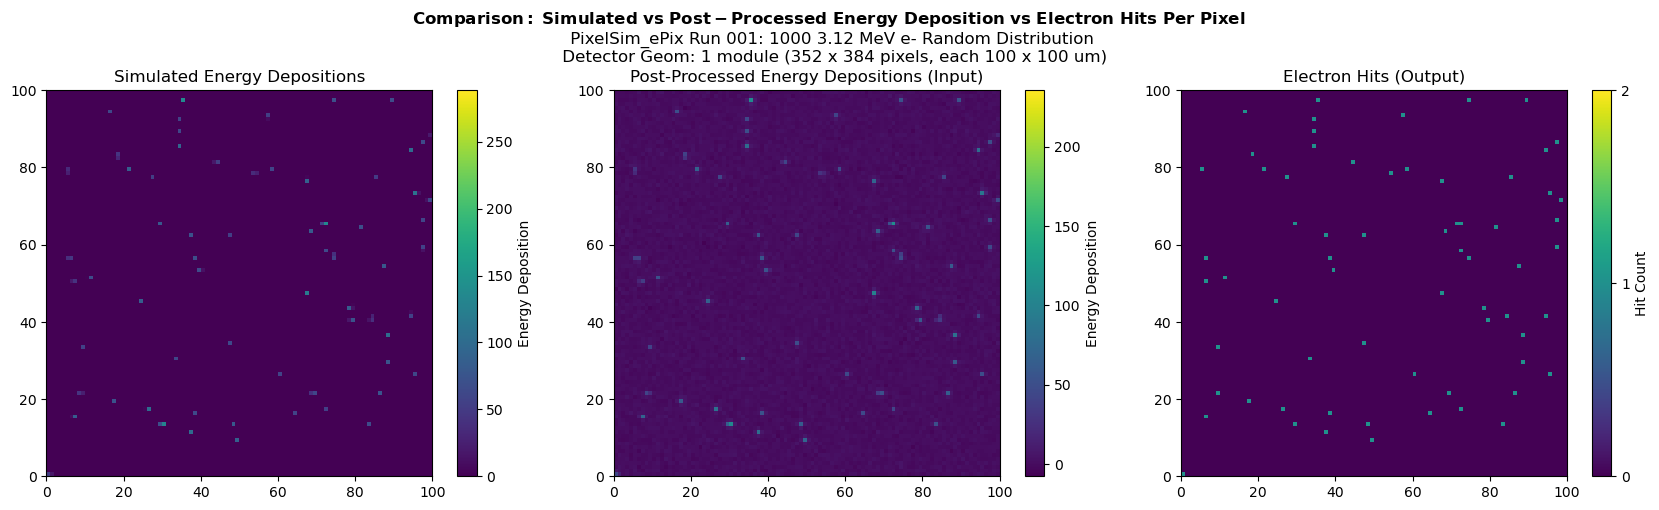

In [240]:
fig,ax=plt.subplots(1,3,figsize=(17,5))
plt.suptitle(r'$\bf{Comparison:\ Simulated\ vs\ Post-Processed\ Energy\ Deposition\ vs\ Electron\ Hits\ Per\ Pixel\ }$' + 
          f" \n PixelSim_ePix Run 001: {int(np.sum(hits[0]))} 3.12 MeV e- Random Distribution " + 
          "\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um)");

titles = ["Simulated Energy Depositions","Post-Processed Energy Depositions (Input)","Electron Hits (Output)"]
cbar_labels=["Energy Deposition (keV)","Energy Deposition (keV)","Hit Count"]
to_plot = [edeps[0].T, digi_edeps[0].T, hits[0]]

'''
for i in range(3):
    ax[i].set_aspect('equal')
    outputs = ax[i].pcolormesh(xedges, yedges, to_plot[i], cmap='viridis')
    ax[i].set_title(titles[i])
    ax[i].figure.colorbar(outputs,label=cbar_labels[i],ax=ax[i]);
    ax[i].set_xlim(0,100)
    ax[i].set_ylim(0,100)
    '''

ax[0].set_aspect('equal')
outputs = ax[0].pcolormesh(xedges, yedges, edeps[0].T, cmap='viridis')
ax[0].set_title("Simulated Energy Depositions")
ax[0].figure.colorbar(outputs,label="Energy Deposition",ax=ax[0]);
ax[0].set_xlim(0,100)
ax[0].set_ylim(0,100)

ax[1].set_aspect('equal')
outputs = ax[1].pcolormesh(xedges, yedges, digi_edeps[0], cmap='viridis')
ax[1].set_title("Post-Processed Energy Depositions (Input)")
ax[1].figure.colorbar(outputs,label="Energy Deposition",ax=ax[1]);
ax[1].set_xlim(0,100)
ax[1].set_ylim(0,100)

ax[2].set_aspect('equal')
inputs = ax[2].pcolormesh(xedges, yedges, hits[0].T, cmap='viridis')
ax[2].set_title("Electron Hits (Output)")
cbar = ax[2].figure.colorbar(inputs,label="Hit Count",ax=ax[2])
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax[2].set_xlim(0,100)
ax[2].set_ylim(0,100)

plt.tight_layout()
plt.show()

In [274]:
from scipy.signal import convolve2d
kernel = np.ones((3,3))
nbhd_sums = convolve2d(edeps[0].T, kernel, mode='same',boundary='fill',fillvalue=0)
result = nbhd_sums * hits[0].T
final_sums = result[result > 0]

In [275]:
kernel2 = np.ones((3,3))
nbhd_sums2 = convolve2d(edeps[1].T, kernel2, mode='same',boundary='fill',fillvalue=0)
result2 = nbhd_sums2 * hits[1].T
final_sums2 = result2[result2 > 0]

In [276]:
fin = np.concatenate((final_sums2,final_sums))

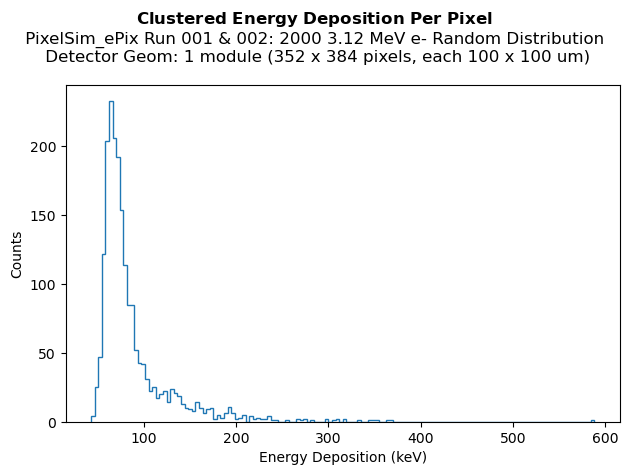

In [277]:
plt.suptitle(r'$\bf{Clustered\ Energy\ Deposition\ Per\ Pixel}$' + 
          f" \n PixelSim_ePix Run 001 & 002: {2*int(np.sum(hits[0]))} 3.12 MeV e- Random Distribution " + 
          "\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um)");
plt.xlabel("Energy Deposition (keV)")
plt.ylabel("Counts")
plt.hist(np.array(fin),bins=140,color='white',edgecolor="C0",histtype='step')
plt.tight_layout()

In [290]:
from scipy.ndimage import label, sum as ndsum
threshold = 4
# Threshold to make binary hit mask
binary_mask = digi_edeps[0] > threshold

# Label connected clusters
labeled_array, num_clusters = label(binary_mask)

# Sum energy per cluster (one value per electron)
cluster_energies = ndsum(edeps[0].T, labeled_array, 
                         range(1, num_clusters + 1))

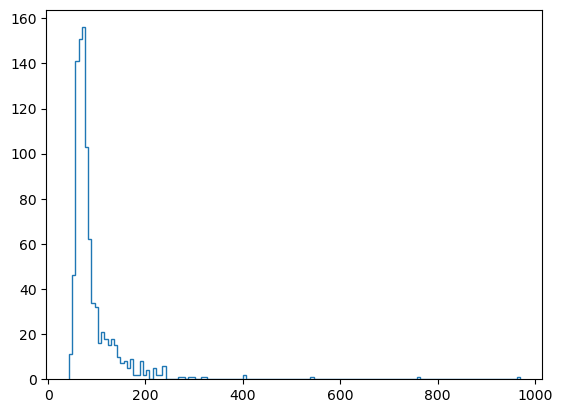

In [291]:
plt.hist(np.array(cluster_energies)[cluster_energies > 10],bins=140,color='white',edgecolor="C0",histtype='step');

(0.0, 50.0)

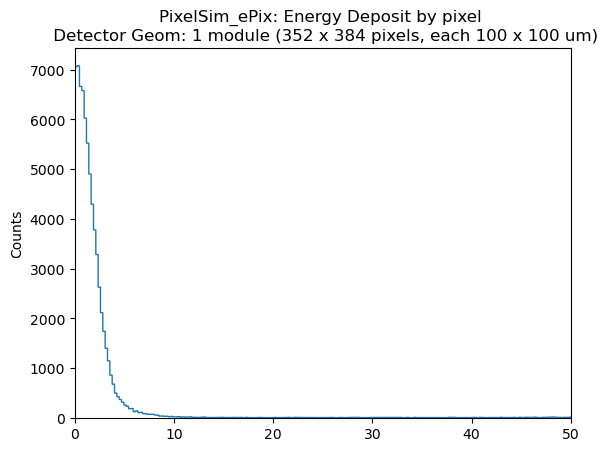

In [234]:
hist = digi_edeps[0].flatten()
cutoff = 0.00
filtered = [x for x in hist if x > cutoff]

plt.hist(np.array(filtered),bins=1000,color="white",edgecolor="C0",histtype='step')
plt.ylabel("Counts")
plt.xlabel(" ")
plt.title("PixelSim_ePix: Energy Deposit by pixel \n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um)");
plt.xlim(0,50)

In [404]:
np.sum(hits_values)

1000.0

In [405]:
counts

array([112411,  20646,   1988,    114,      9])

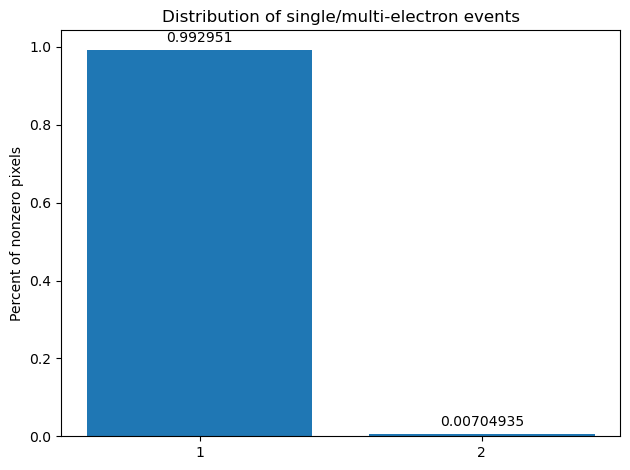

In [406]:
nums, counts = np.unique(hits_values.flatten(), return_counts=True)
nums_nonzero = nums[1:]
counts_nonzero = counts[1:]
percents = (counts_nonzero / np.sum(counts_nonzero))
bars = plt.bar(nums_nonzero,percents)
plt.bar_label(bars,padding=3)
plt.title("Distribution of single/multi-electron events")
plt.ylabel("Percent of nonzero pixels")
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()

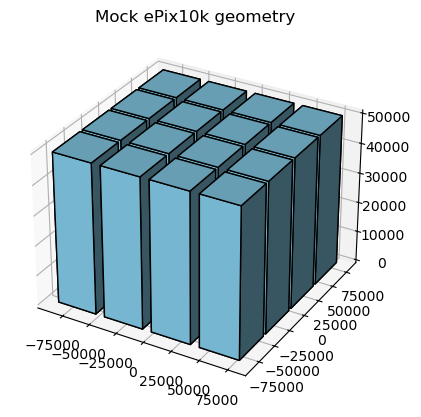

In [410]:
xs = []
ys = []
zs = [0]*16

dx = np.array([352*100]*16)
dy = np.array([384*100]*16)
dz = np.array([500*100]*16)

for i in range(4):
    for j in range(4):
        xPos = (i - 2) * (352 + 80.667)*100;
        yPos = (j - 2) * (384 + 38)*100;
        xs.append(xPos)
        ys.append(yPos)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.bar3d(xs, ys, zs, dx, dy, dz, color='skyblue', edgecolor='black')
plt.title("Mock ePix10k geometry");